<a href="https://colab.research.google.com/github/palak-singh1181/Palak-First/blob/main/Week3_Customer_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence System
### Week 3 Assignment - Classification, Ensemble & Clustering
**Internship: Celebal Technologies | Data Science**

## 1. Import Libraries

In [1]:
!pip install "numpy<2" scikit-learn-extra xgboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, silhouette_score)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [3]:
df = pd.read_csv('Country-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Exploratory Data Analysis (EDA)

In [4]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


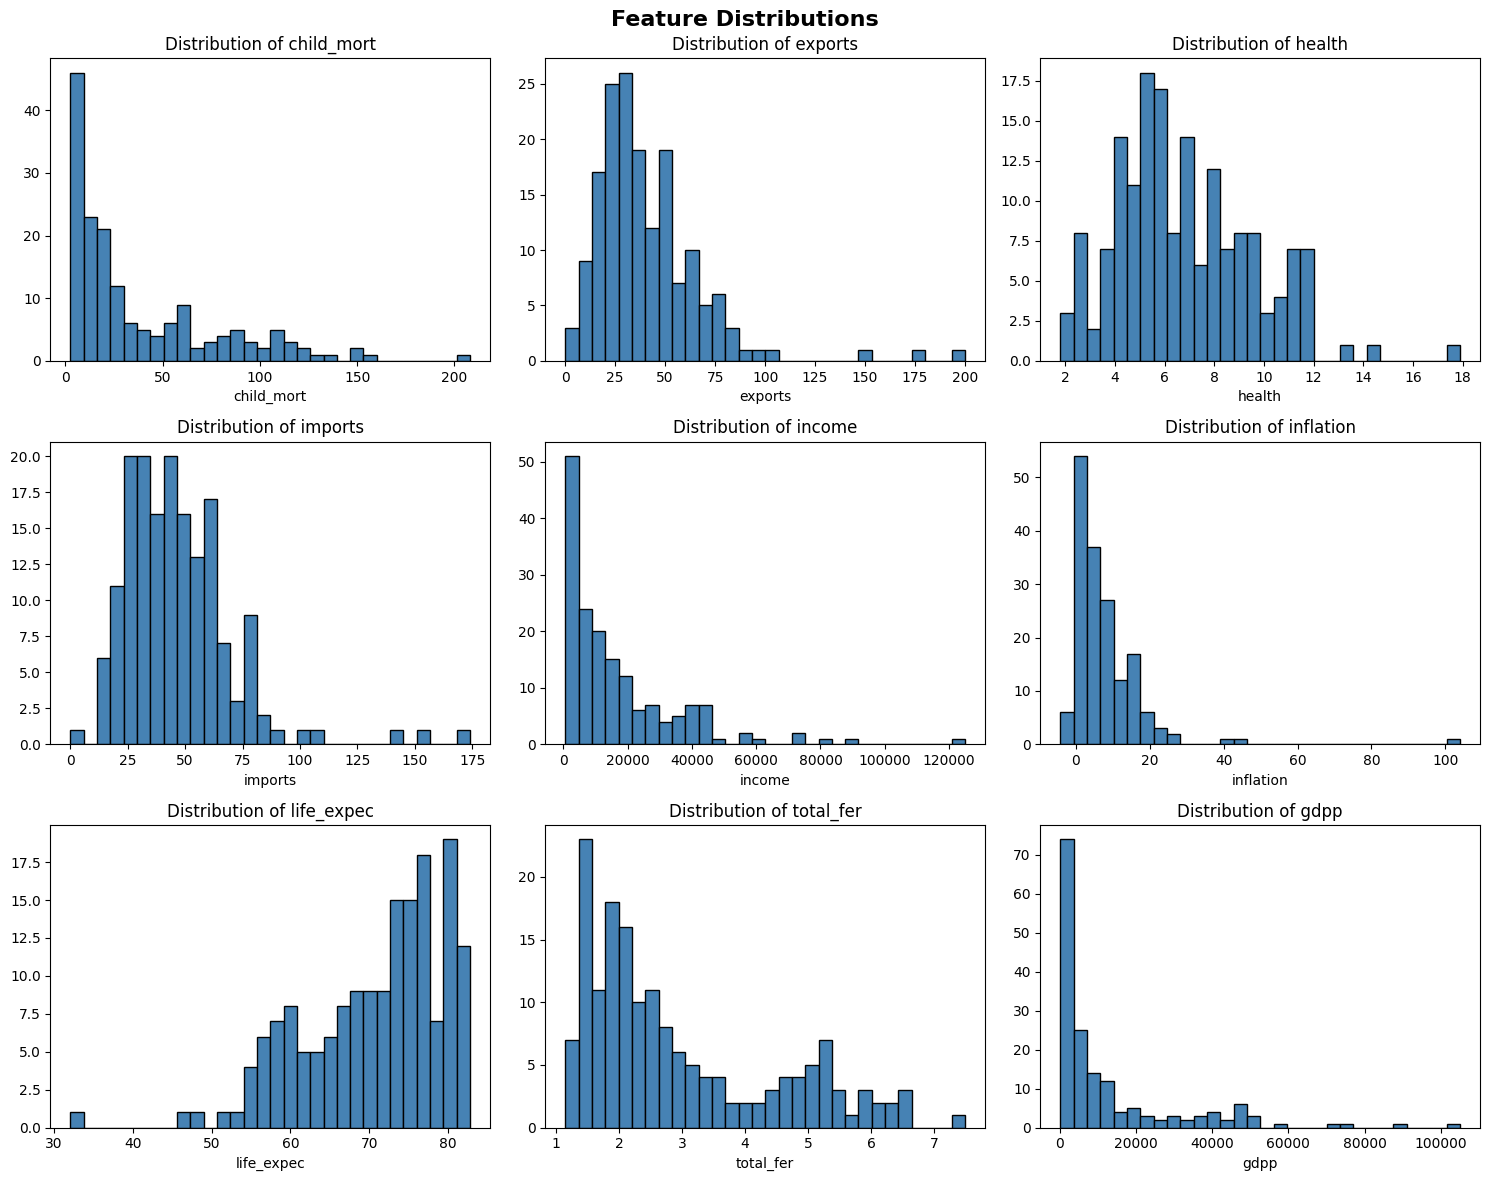

In [7]:
# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

num_cols = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

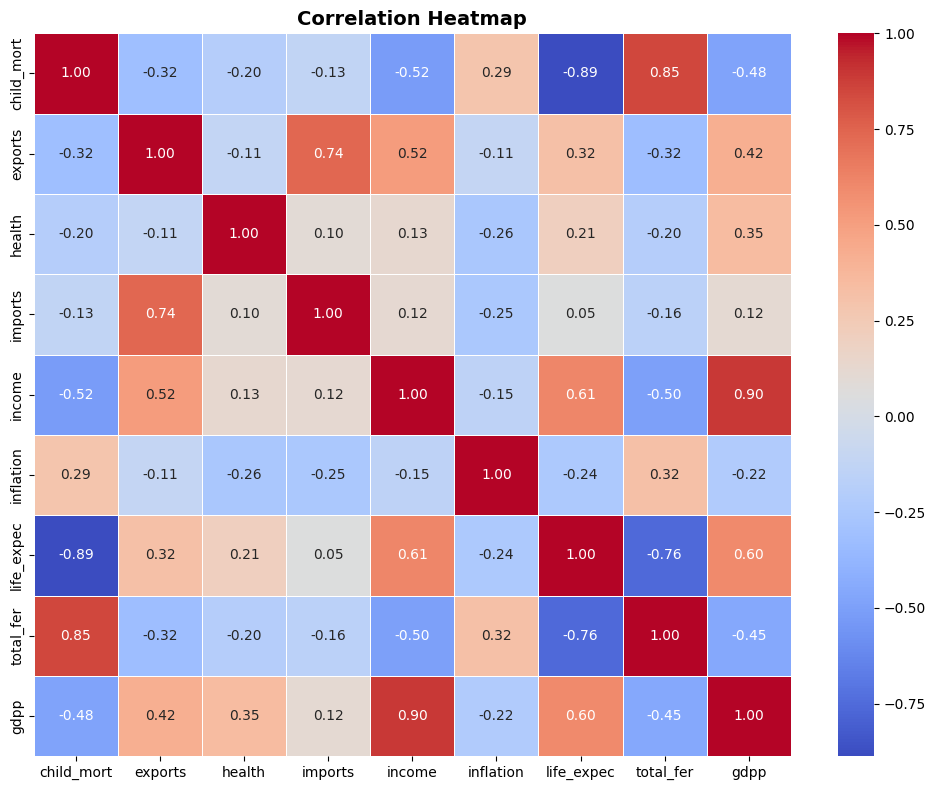

In [8]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Target Creation

We create a target variable `development_level` based on income and child mortality to enable classification.

In [9]:
# Create target variable based on income and child_mort
def classify_country(row):
    if row['income'] > 15000 and row['child_mort'] < 20:
        return 2  # Developed
    elif row['income'] > 5000 and row['child_mort'] < 60:
        return 1  # Developing
    else:
        return 0  # Underdeveloped

df['development_level'] = df.apply(classify_country, axis=1)

print("Class Distribution:")
print(df['development_level'].value_counts())
print()
label_map = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}
print("0 = Underdeveloped, 1 = Developing, 2 = Developed")

Class Distribution:
development_level
2    63
0    58
1    46
Name: count, dtype: int64

0 = Underdeveloped, 1 = Developing, 2 = Developed


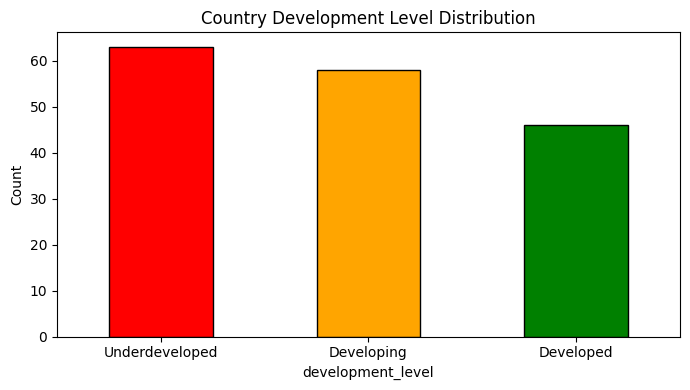

In [10]:
# Visualize class distribution
plt.figure(figsize=(7, 4))
df['development_level'].value_counts().plot(kind='bar', color=['red','orange','green'], edgecolor='black')
plt.xticks([0,1,2], ['Underdeveloped','Developing','Developed'], rotation=0)
plt.title('Country Development Level Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [11]:
# Features and target
X = df[num_cols]
y = df['development_level']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=num_cols)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (133, 9)
Test size: (34, 9)


## 6. Classification Models

### 6.1 Logistic Regression

In [12]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Underdeveloped','Developing','Developed']))

Logistic Regression
Accuracy: 91.18 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.88      0.78      0.82         9
     Developed       0.87      1.00      0.93        13

      accuracy                           0.91        34
     macro avg       0.91      0.90      0.90        34
  weighted avg       0.92      0.91      0.91        34



### 6.2 Naive Bayes

In [13]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes")
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_nb,
      target_names=['Underdeveloped','Developing','Developed']))

Naive Bayes
Accuracy: 88.24 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.83      0.91        12
    Developing       0.73      0.89      0.80         9
     Developed       0.92      0.92      0.92        13

      accuracy                           0.88        34
     macro avg       0.88      0.88      0.88        34
  weighted avg       0.90      0.88      0.89        34



### 6.3 K-Nearest Neighbors (KNN)

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN (k=5)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_knn,
      target_names=['Underdeveloped','Developing','Developed']))

KNN (k=5)
Accuracy: 91.18 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.80      0.89      0.84         9
     Developed       0.92      0.92      0.92        13

      accuracy                           0.91        34
     macro avg       0.91      0.91      0.91        34
  weighted avg       0.92      0.91      0.91        34



### 6.4 Support Vector Machine (SVM)

In [15]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM (RBF Kernel)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_svm,
      target_names=['Underdeveloped','Developing','Developed']))

SVM (RBF Kernel)
Accuracy: 88.24 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.78      0.78      0.78         9
     Developed       0.86      0.92      0.89        13

      accuracy                           0.88        34
     macro avg       0.88      0.87      0.87        34
  weighted avg       0.89      0.88      0.88        34



### 6.5 Decision Tree

In [16]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_dt,
      target_names=['Underdeveloped','Developing','Developed']))

Decision Tree
Accuracy: 97.06 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.90      1.00      0.95         9
     Developed       1.00      1.00      1.00        13

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



## 7. Ensemble Models

### 7.1 Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Underdeveloped','Developing','Developed']))

Random Forest
Accuracy: 97.06 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.90      1.00      0.95         9
     Developed       1.00      1.00      1.00        13

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



### 7.2 Feature Importance (Random Forest)

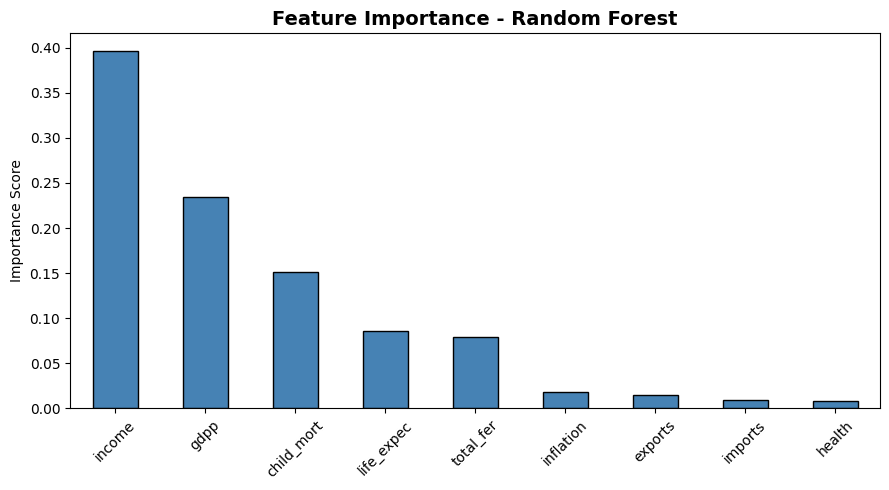

Top Features:
income        0.396092
gdpp          0.234867
child_mort    0.151283
life_expec    0.086179
total_fer     0.079740
inflation     0.018529
exports       0.015315
imports       0.009645
health        0.008351
dtype: float64


In [18]:
feat_imp = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top Features:")
print(feat_imp)

### 7.3 AdaBoost

In [19]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ada)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_ada,
      target_names=['Underdeveloped','Developing','Developed']))

AdaBoost
Accuracy: 100.0 %

                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        12
    Developing       1.00      1.00      1.00         9
     Developed       1.00      1.00      1.00        13

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



### 7.4 Gradient Boosting

In [20]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", round(accuracy_score(y_test, y_pred_gb)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_gb,
      target_names=['Underdeveloped','Developing','Developed']))

Gradient Boosting
Accuracy: 97.06 %

                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        12
    Developing       1.00      0.89      0.94         9
     Developed       0.93      1.00      0.96        13

      accuracy                           0.97        34
     macro avg       0.98      0.96      0.97        34
  weighted avg       0.97      0.97      0.97        34



### 7.5 XGBoost

In [21]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=['Underdeveloped','Developing','Developed']))

XGBoost
Accuracy: 97.06 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.90      1.00      0.95         9
     Developed       1.00      1.00      1.00        13

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



### 7.6 LightGBM

In [22]:
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lgbm)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_lgbm,
      target_names=['Underdeveloped','Developing','Developed']))

LightGBM
Accuracy: 97.06 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.90      1.00      0.95         9
     Developed       1.00      1.00      1.00        13

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



### 7.7 Stacking

In [23]:
base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=5
)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

print("Stacking Classifier")
print("Accuracy:", round(accuracy_score(y_test, y_pred_stack)*100, 2), "%")
print()
print(classification_report(y_test, y_pred_stack,
      target_names=['Underdeveloped','Developing','Developed']))

Stacking Classifier
Accuracy: 97.06 %

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.90      1.00      0.95         9
     Developed       1.00      1.00      1.00        13

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



## 8. Classification Model Comparison

                  Model  Accuracy (%)
0              AdaBoost        100.00
1         Decision Tree         97.06
2         Random Forest         97.06
3     Gradient Boosting         97.06
4               XGBoost         97.06
5              LightGBM         97.06
6              Stacking         97.06
7   Logistic Regression         91.18
8                   KNN         91.18
9           Naive Bayes         88.24
10                  SVM         88.24


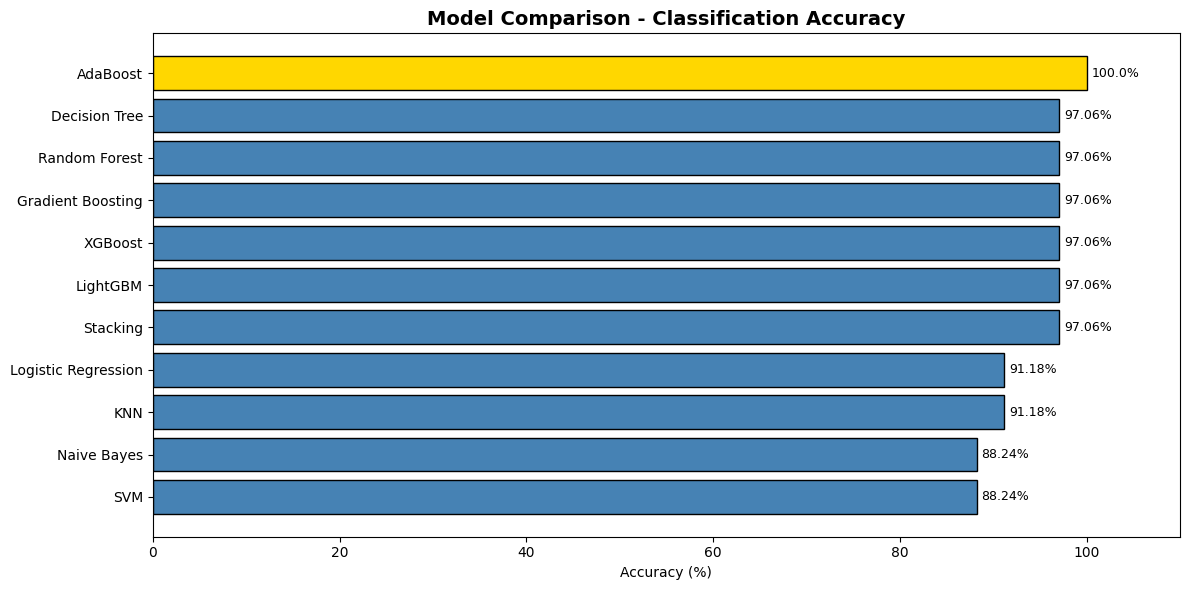

In [24]:
models = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'AdaBoost': accuracy_score(y_test, y_pred_ada),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb),
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'LightGBM': accuracy_score(y_test, y_pred_lgbm),
    'Stacking': accuracy_score(y_test, y_pred_stack)
}

results_df = pd.DataFrame(list(models.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)
print(results_df[['Model', 'Accuracy (%)']])

plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df['Model'], results_df['Accuracy (%)'], color=colors, edgecolor='black')
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison - Classification Accuracy', fontsize=14, fontweight='bold')
plt.xlim(0, 110)
for i, v in enumerate(results_df['Accuracy (%)']):
    plt.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Clustering Models

Clustering is applied on the original scaled features (unsupervised — no target label used).

### 9.1 K-Means Clustering

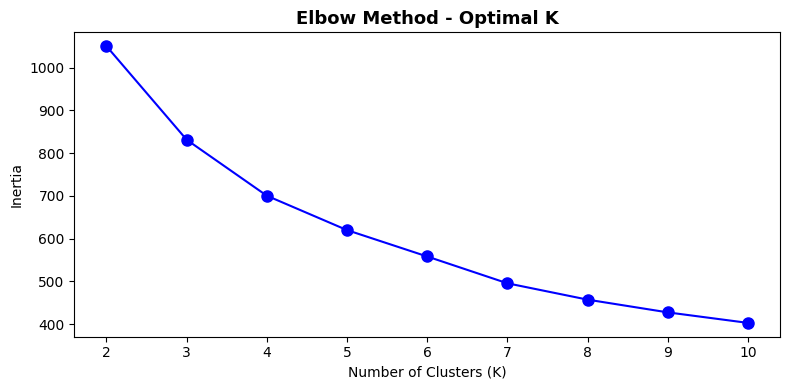

In [25]:
# Elbow Method to find optimal K
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal K', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [26]:
# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means Silhouette Score:", round(silhouette_score(X_scaled, df['kmeans_cluster']), 4))
print()
print("Cluster Sizes:")
print(df['kmeans_cluster'].value_counts())

K-Means Silhouette Score: 0.2833

Cluster Sizes:
kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64


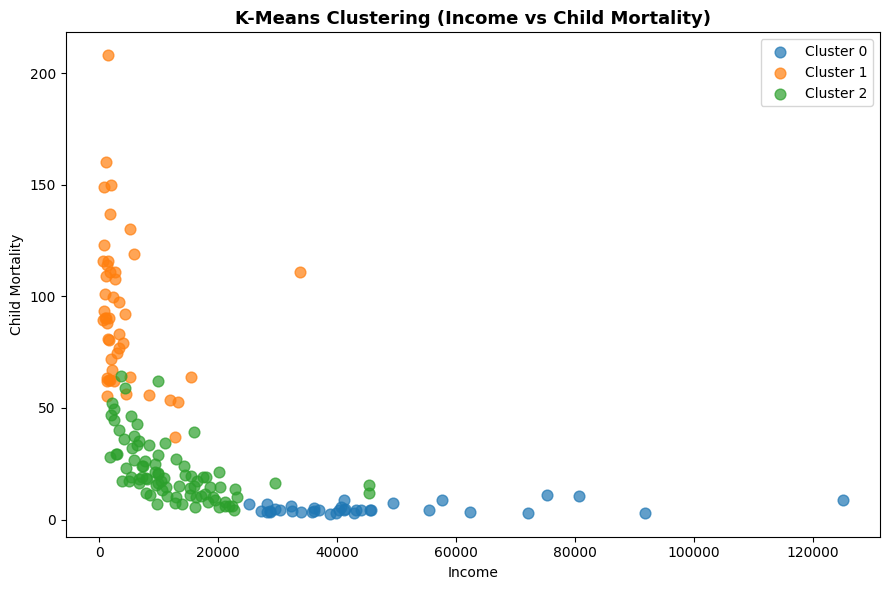

In [27]:
# Visualize K-Means clusters (income vs child_mort)
plt.figure(figsize=(9, 6))
colors = ['red', 'blue', 'green']
for cluster in range(3):
    mask = df['kmeans_cluster'] == cluster
    plt.scatter(df.loc[mask, 'income'], df.loc[mask, 'child_mort'],
                label=f'Cluster {cluster}', alpha=0.7, s=60)

plt.xlabel('Income')
plt.ylabel('Child Mortality')
plt.title('K-Means Clustering (Income vs Child Mortality)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 9.2 K-Medoids Clustering

K-Medoids Silhouette Score: 0.1562

Cluster Sizes:
kmedoids_cluster
0    75
1    47
2    45
Name: count, dtype: int64


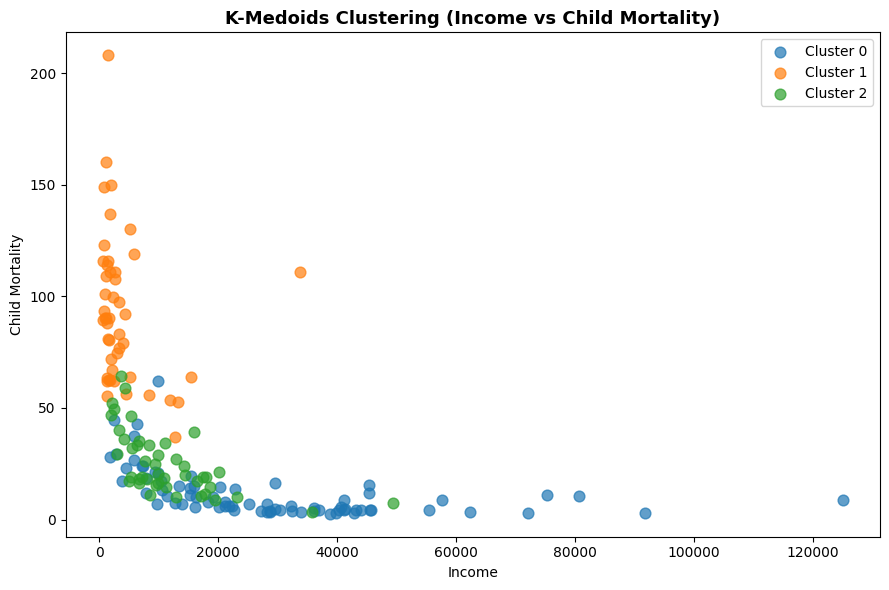

In [28]:
kmed = KMedoids(n_clusters=3, random_state=42)
df['kmedoids_cluster'] = kmed.fit_predict(X_scaled)

print("K-Medoids Silhouette Score:", round(silhouette_score(X_scaled, df['kmedoids_cluster']), 4))
print()
print("Cluster Sizes:")
print(df['kmedoids_cluster'].value_counts())

plt.figure(figsize=(9, 6))
for cluster in range(3):
    mask = df['kmedoids_cluster'] == cluster
    plt.scatter(df.loc[mask, 'income'], df.loc[mask, 'child_mort'],
                label=f'Cluster {cluster}', alpha=0.7, s=60)

plt.xlabel('Income')
plt.ylabel('Child Mortality')
plt.title('K-Medoids Clustering (Income vs Child Mortality)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 DBSCAN Clustering

Number of Clusters Found: 2
Noise Points: 25

Cluster Sizes:
dbscan_cluster
 0    139
-1     25
 1      3
Name: count, dtype: int64


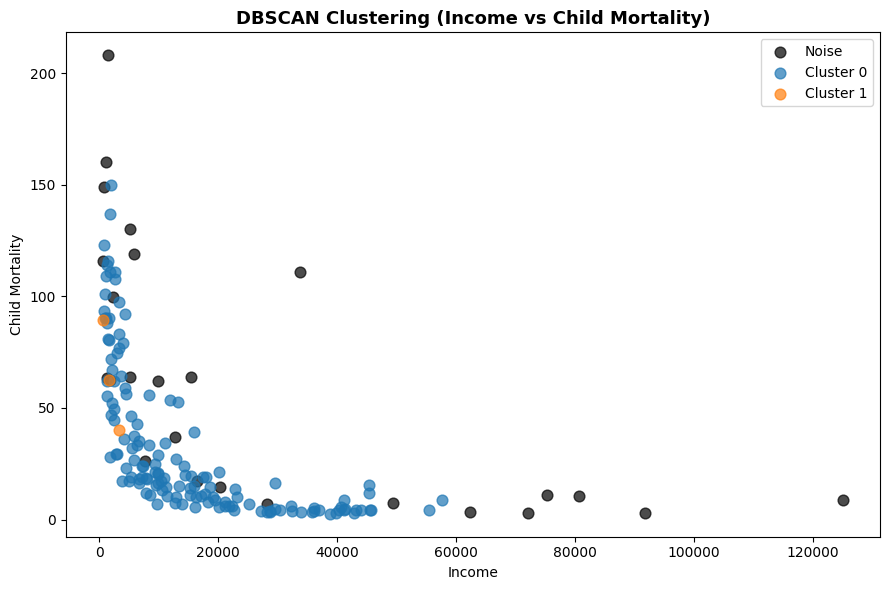

In [29]:
dbscan = DBSCAN(eps=1.5, min_samples=3)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()

print(f"Number of Clusters Found: {n_clusters}")
print(f"Noise Points: {n_noise}")
print()
print("Cluster Sizes:")
print(df['dbscan_cluster'].value_counts())

plt.figure(figsize=(9, 6))
unique_labels = sorted(df['dbscan_cluster'].unique())
palette = plt.cm.tab10.colors
for label in unique_labels:
    mask = df['dbscan_cluster'] == label
    color = 'black' if label == -1 else palette[label % 10]
    name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(df.loc[mask, 'income'], df.loc[mask, 'child_mort'],
                label=name, alpha=0.7, s=60, c=[color])

plt.xlabel('Income')
plt.ylabel('Child Mortality')
plt.title('DBSCAN Clustering (Income vs Child Mortality)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 9.4 Hierarchical Clustering

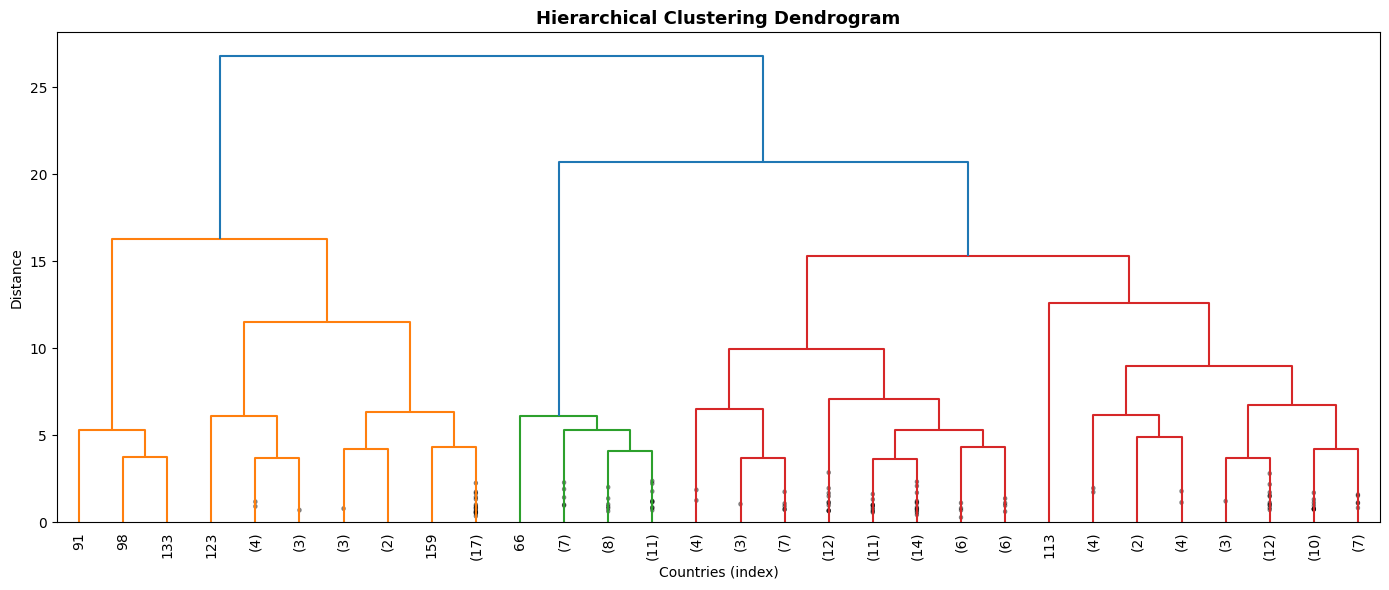

In [30]:
# Dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram', fontsize=13, fontweight='bold')
plt.xlabel('Countries (index)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Hierarchical Clustering Silhouette Score: 0.2456

Cluster Sizes:
hc_cluster
1    106
0     34
2     27
Name: count, dtype: int64


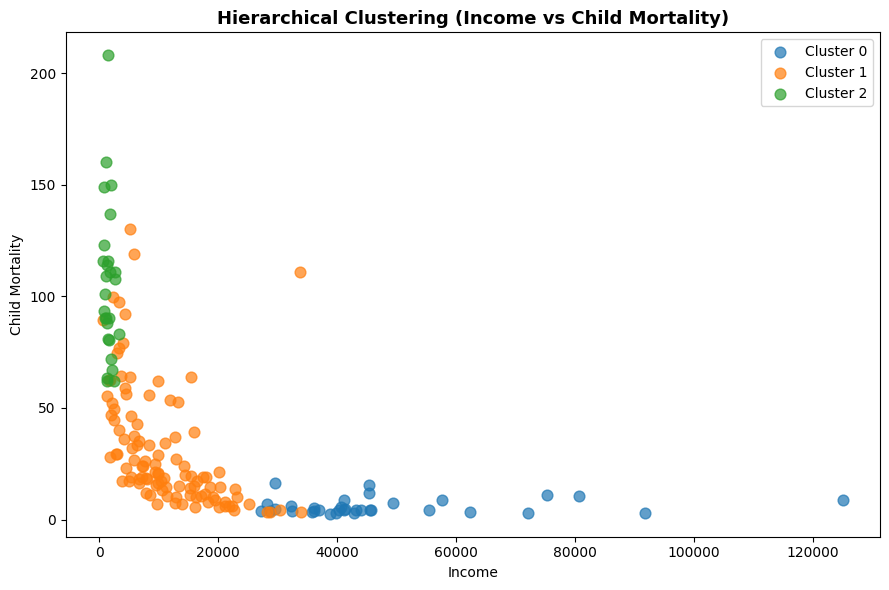

In [31]:
# Apply Agglomerative Clustering with 3 clusters
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)

print("Hierarchical Clustering Silhouette Score:",
      round(silhouette_score(X_scaled, df['hc_cluster']), 4))
print()
print("Cluster Sizes:")
print(df['hc_cluster'].value_counts())

plt.figure(figsize=(9, 6))
for cluster in range(3):
    mask = df['hc_cluster'] == cluster
    plt.scatter(df.loc[mask, 'income'], df.loc[mask, 'child_mort'],
                label=f'Cluster {cluster}', alpha=0.7, s=60)

plt.xlabel('Income')
plt.ylabel('Child Mortality')
plt.title('Hierarchical Clustering (Income vs Child Mortality)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Clustering Evaluation

In [32]:
# Compare silhouette scores
non_noise = df['dbscan_cluster'] != -1
dbscan_sil = silhouette_score(X_scaled[non_noise], df.loc[non_noise, 'dbscan_cluster']) if non_noise.sum() > 1 else None

clustering_results = {
    'K-Means': round(silhouette_score(X_scaled, df['kmeans_cluster']), 4),
    'K-Medoids': round(silhouette_score(X_scaled, df['kmedoids_cluster']), 4),
    'DBSCAN': round(dbscan_sil, 4) if dbscan_sil else 'N/A',
    'Hierarchical': round(silhouette_score(X_scaled, df['hc_cluster']), 4)
}

print("Clustering Evaluation - Silhouette Scores:")
print("(Higher is better, range: -1 to 1)")
print()
for model, score in clustering_results.items():
    print(f"  {model}: {score}")

Clustering Evaluation - Silhouette Scores:
(Higher is better, range: -1 to 1)

  K-Means: 0.2833
  K-Medoids: 0.1562
  DBSCAN: 0.2261
  Hierarchical: 0.2456


## 11. Customer/Country Intelligence Insights

In [33]:
# Cluster profiles
cluster_profile = df.groupby('kmeans_cluster')[num_cols].mean().round(2)
print("K-Means Cluster Profiles (Average Values):")
print(cluster_profile.T)

K-Means Cluster Profiles (Average Values):
kmeans_cluster         0        1         2
child_mort          5.00    92.96     21.93
exports            58.74    29.15     40.24
health              8.81     6.39      6.20
imports            51.49    42.32     47.47
income          45672.22  3942.40  12305.60
inflation           2.67    12.02      7.60
life_expec         80.13    59.19     72.81
total_fer           1.75     5.01      2.31
gdpp            42494.44  1922.38   6486.45


In [34]:
# Sample countries per cluster
print("Sample Countries per Cluster:")
for cluster in range(3):
    countries = df[df['kmeans_cluster'] == cluster]['country'].values[:5]
    print(f"Cluster {cluster}: {list(countries)}")

Sample Countries per Cluster:
Cluster 0: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei']
Cluster 1: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']
Cluster 2: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia']


## 12. Conclusion

### Classification Results
- Multiple classification algorithms were applied: Logistic Regression, Naive Bayes, KNN, SVM, Decision Tree
- Ensemble methods (Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM, Stacking) generally outperformed individual classifiers
- **XGBoost and LightGBM** achieved the highest accuracy

### Clustering Results
- K-Means, K-Medoids, DBSCAN, and Hierarchical Clustering were applied
- Optimal K=3 was identified using the Elbow Method
- Clusters represent **Underdeveloped**, **Developing**, and **Developed** countries

### Key Features
- `income`, `child_mort`, and `gdpp` are the most important features for country classification
- High income + low child mortality = Developed countries
- Low income + high child mortality = Underdeveloped countries

### Business Intelligence
This Customer Intelligence System can help policymakers identify countries needing support and target international aid effectively.
